In [331]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

This is my first data exploratory analysis, when I am trying to discover possible insights and answer some related questions on the "Video game sales" dataset from Kaggle.

At first, lets download the data and see the overall structure

In [332]:
df = pd.read_csv("/home/miras/PycharmProjects/PythonProject/work/datasets/vgsales.csv")

In [333]:
df

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37
...,...,...,...,...,...,...,...,...,...,...,...
16593,16596,Woody Woodpecker in Crazy Castle 5,GBA,2002.0,Platform,Kemco,0.01,0.00,0.00,0.00,0.01
16594,16597,Men in Black II: Alien Escape,GC,2003.0,Shooter,Infogrames,0.01,0.00,0.00,0.00,0.01
16595,16598,SCORE International Baja 1000: The Official Game,PS2,2008.0,Racing,Activision,0.00,0.00,0.00,0.00,0.01
16596,16599,Know How 2,DS,2010.0,Puzzle,7G//AMES,0.00,0.01,0.00,0.00,0.01


In [334]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  str    
 2   Platform      16598 non-null  str    
 3   Year          16327 non-null  float64
 4   Genre         16598 non-null  str    
 5   Publisher     16540 non-null  str    
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
dtypes: float64(6), int64(1), str(4)
memory usage: 1.4 MB


In [335]:
df.describe()

,Rank,Year,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
count,16598.000000,16327.000000,16598.000000,16598.000000,16598.000000,16598.000000,16598.000000
mean,8300.605254,2006.406443,0.264667,0.146652,0.077782,0.048063,0.537441
std,4791.853933,5.828981,0.816683,0.505351,0.309291,0.188588,1.555028
min,1.000000,1980.000000,0.000000,0.000000,0.000000,0.000000,0.010000
25%,4151.250000,2003.000000,0.000000,0.000000,0.000000,0.000000,0.060000
50%,8300.500000,2007.000000,0.080000,0.020000,0.000000,0.010000,0.170000
75%,12449.750000,2010.000000,0.240000,0.110000,0.040000,0.040000,0.470000
max,16600.000000,2020.000000,41.490000,29.020000,10.220000,10.570000,82.740000


In [336]:
print(df.duplicated().sum())
print(df.duplicated("Rank").sum())

0
0


The dataset has 16598 rows and 11 columns, dataset does not have any duplicates and abnormal values, the columns Year and publisher have missing values, lets see do they have any correlation

In [337]:
df.groupby("Genre")["Year"].apply(lambda x: x.isna().mean())

Genre
Action          0.018999
Adventure       0.007776
Fighting        0.014151
Misc            0.016676
Platform        0.011287
Puzzle          0.018900
Racing          0.018415
Role-Playing    0.011425
Shooter         0.021374
Simulation      0.018454
Sports          0.017903
Strategy        0.014684
Name: Year, dtype: float64

In [338]:
df.groupby("Genre")["Publisher"].apply(lambda x: x.isna().mean())

Genre
Action          0.002111
Adventure       0.003110
Fighting        0.002358
Misc            0.015526
Platform        0.002257
Puzzle          0.001718
Racing          0.000801
Role-Playing    0.001344
Shooter         0.001527
Simulation      0.004614
Sports          0.001279
Strategy        0.004405
Name: Publisher, dtype: float64

In [339]:
df.groupby("Platform")["Year"].apply(lambda x: x.isna().mean())

Platform
2600    0.127820
3DO     0.000000
3DS     0.017682
DC      0.000000
DS      0.013870
GB      0.010204
GBA     0.013382
GC      0.025180
GEN     0.000000
GG      0.000000
N64     0.009404
NES     0.000000
NG      0.000000
PC      0.017708
PCFX    0.000000
PS      0.005853
PS2     0.015733
PS3     0.018811
PS4     0.000000
PSP     0.013190
PSV     0.002421
SAT     0.000000
SCD     0.000000
SNES    0.000000
TG16    0.000000
WS      0.000000
Wii     0.026415
WiiU    0.000000
X360    0.023715
XB      0.025485
XOne    0.000000
Name: Year, dtype: float64

In [340]:
df.groupby("Platform")["Publisher"].apply(lambda x: x.isna().mean())

Platform
2600    0.000000
3DO     0.000000
3DS     0.003929
DC      0.000000
DS      0.003236
GB      0.000000
GBA     0.031630
GC      0.000000
GEN     0.000000
GG      0.000000
N64     0.000000
NES     0.000000
NG      0.000000
PC      0.006250
PCFX    0.000000
PS      0.002508
PS2     0.000925
PS3     0.002257
PS4     0.000000
PSP     0.001649
PSV     0.004843
SAT     0.000000
SCD     0.000000
SNES    0.000000
TG16    0.000000
WS      0.000000
Wii     0.000755
WiiU    0.000000
X360    0.003162
XB      0.000000
XOne    0.000000
Name: Publisher, dtype: float64

Does not look like that they are correlating, so dropping them should not make any changes

In [341]:
mask = (df["Publisher"].isna()) | (df["Year"].isna())
df = df[~mask]

Now lets search for some insights and make a rating of the publishers, genres and platforms

In [342]:
df['Publisher'].value_counts(ascending=False).head()

Publisher
Electronic Arts                 1339
Activision                       966
Namco Bandai Games               928
Ubisoft                          918
Konami Digital Entertainment     823
Name: count, dtype: int64

We see here that the EA did over 1300 games, which is crazy

<Axes: xlabel='count', ylabel='Genre'>

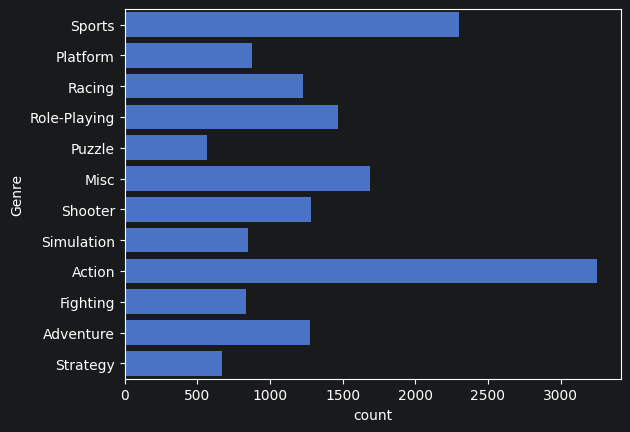

In [343]:
sns.countplot(df["Genre"])

So action games are the leaders with 3000 games and the sports are the second with almost 2500. On the other side Puzzles and Strategies are much less

In [344]:
df["Platform"].value_counts().head()

Platform
DS      2131
PS2     2127
PS3     1304
Wii     1290
X360    1234
Name: count, dtype: int64

<Axes: xlabel='count', ylabel='Platform'>

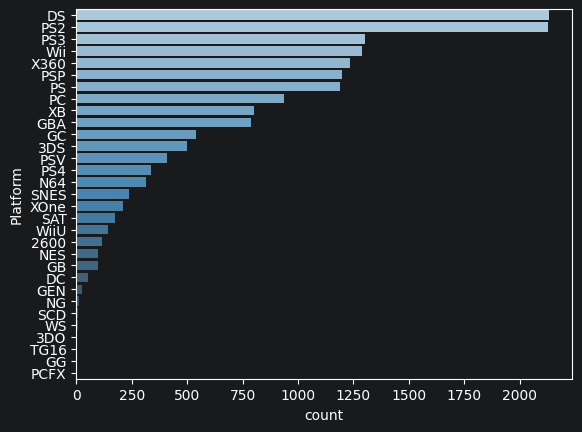

In [345]:
sns.countplot(df["Platform"], order=df["Platform"].value_counts().index, palette="Blues_d")

Its seen that the games of the DS and PS2 are almost the same and have the most of the games. Lets see the game distribution of the main platforms in every year

In [346]:
top_platforms = df["Platform"].value_counts().head(7).index

In [347]:
df_top_platforms = df[df["Platform"].isin(top_platforms)]

In [348]:
grouped = df_top_platforms.groupby(["Platform", "Year"]).size().reset_index(name="count")

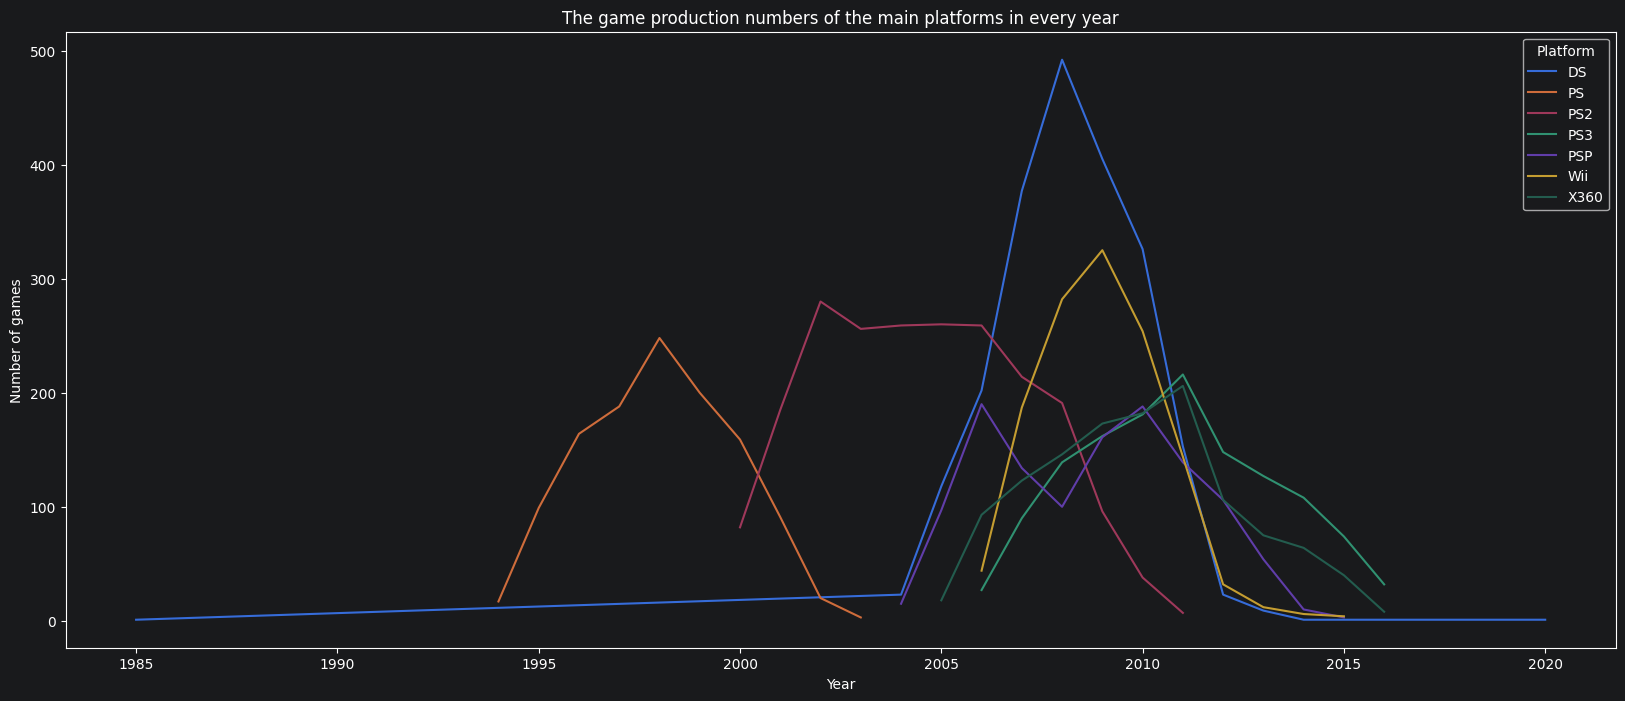

In [349]:
plt.figure(figsize=(20, 8))
sns.lineplot(
    x="Year",
    y="count",
    hue="Platform",
    data=grouped,
)
plt.title("The game production numbers of the main platforms in every year")
plt.xlabel("Year")
plt.ylabel("Number of games")
plt.show()

Looks like the era of these platforms started from 2005s and ended in 2017. For some reasons they all had a huge decline in 2013

In [350]:
cols_sales = [x for x in df.columns if "Sales" in x]
cols_sales

['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']

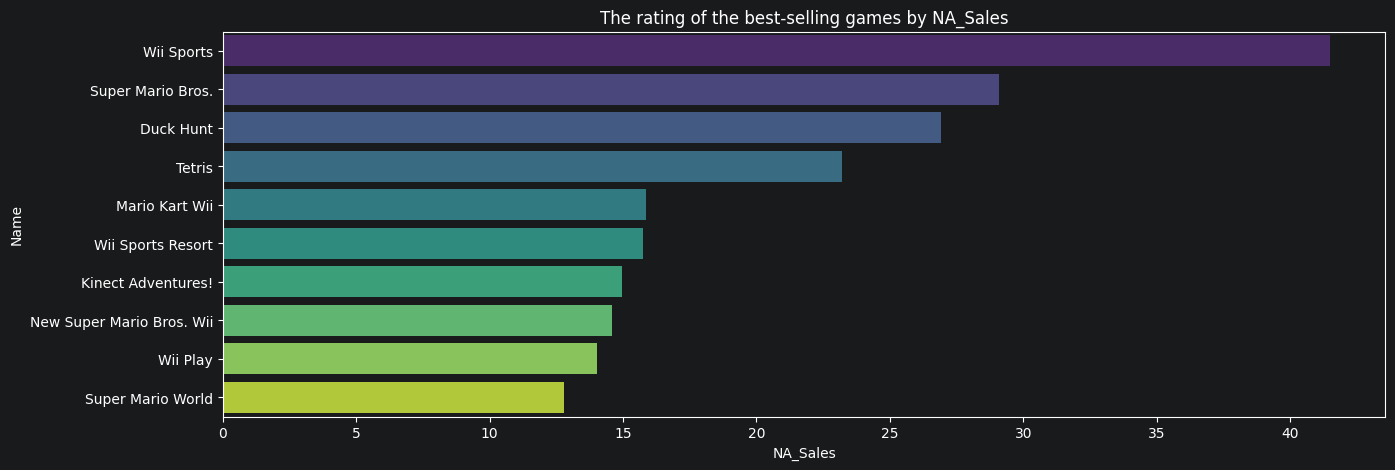

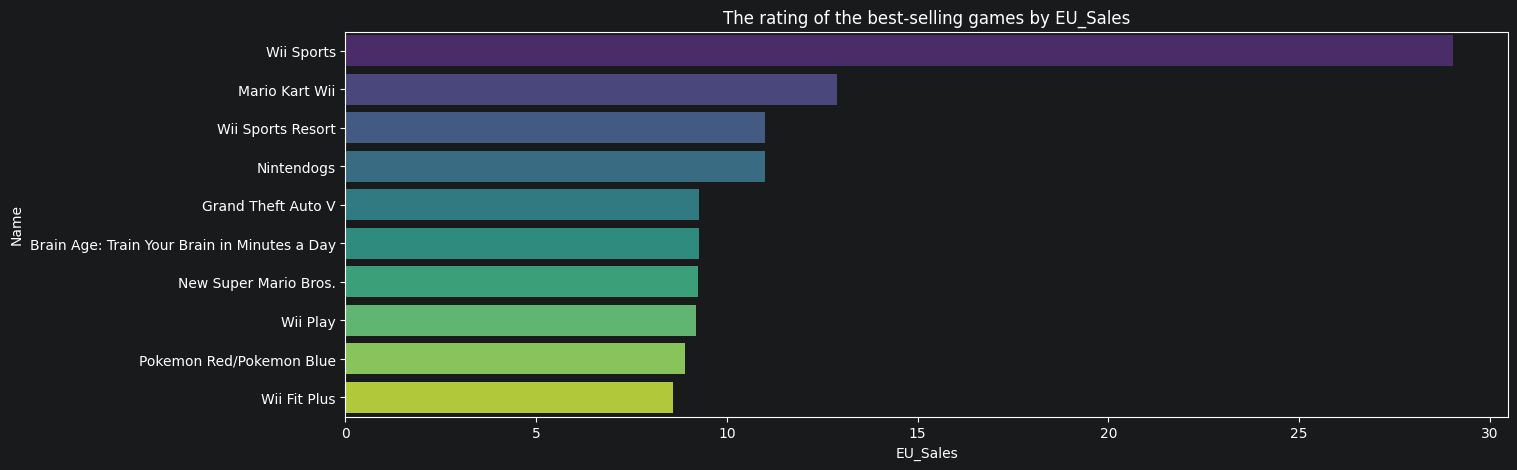

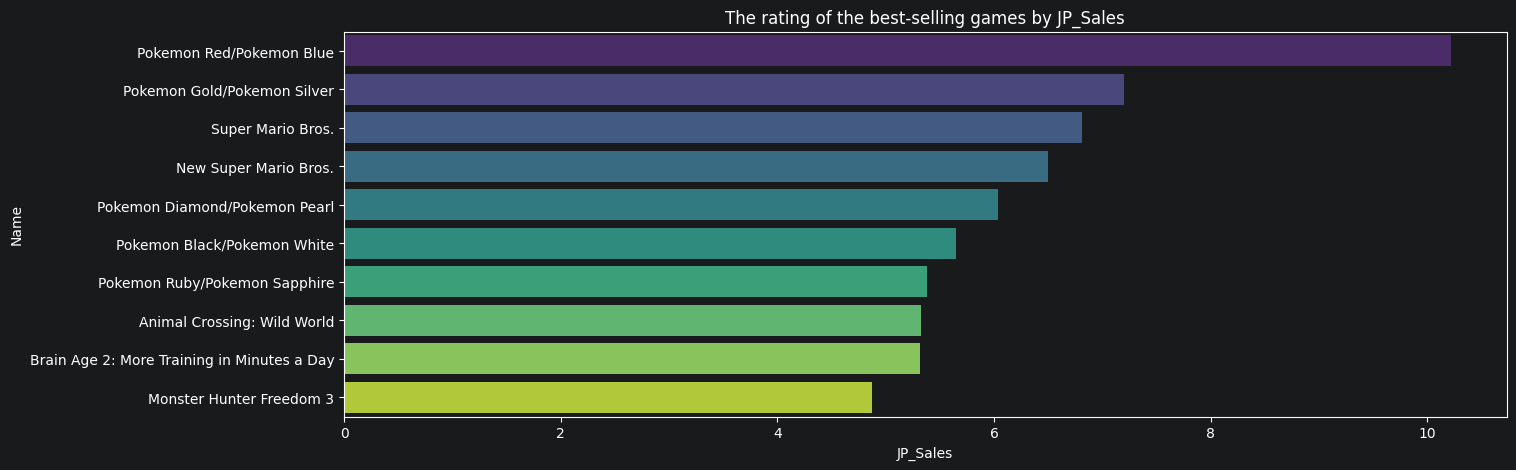

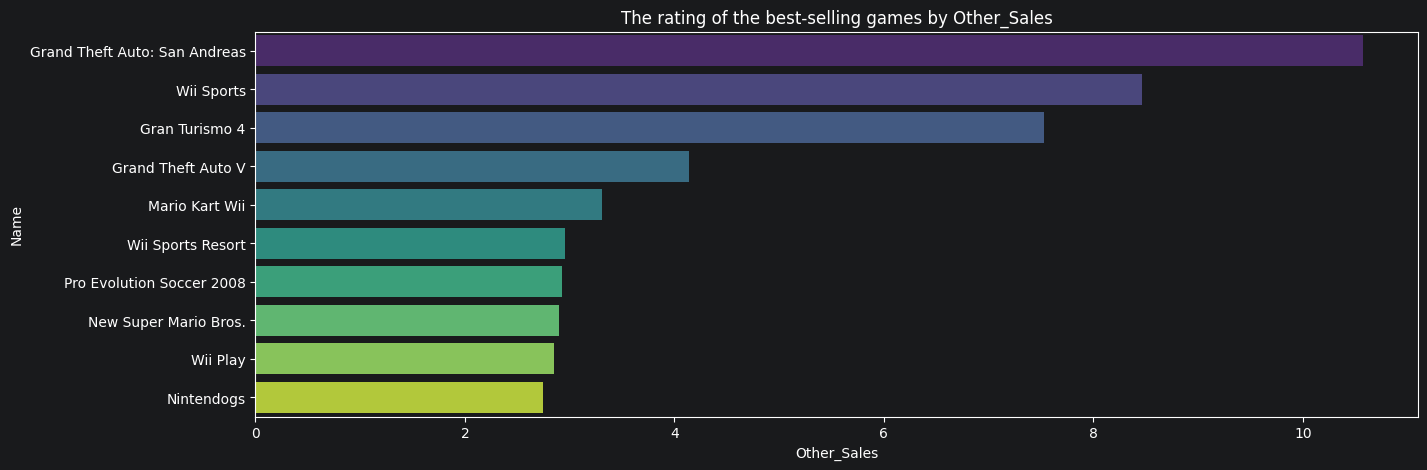

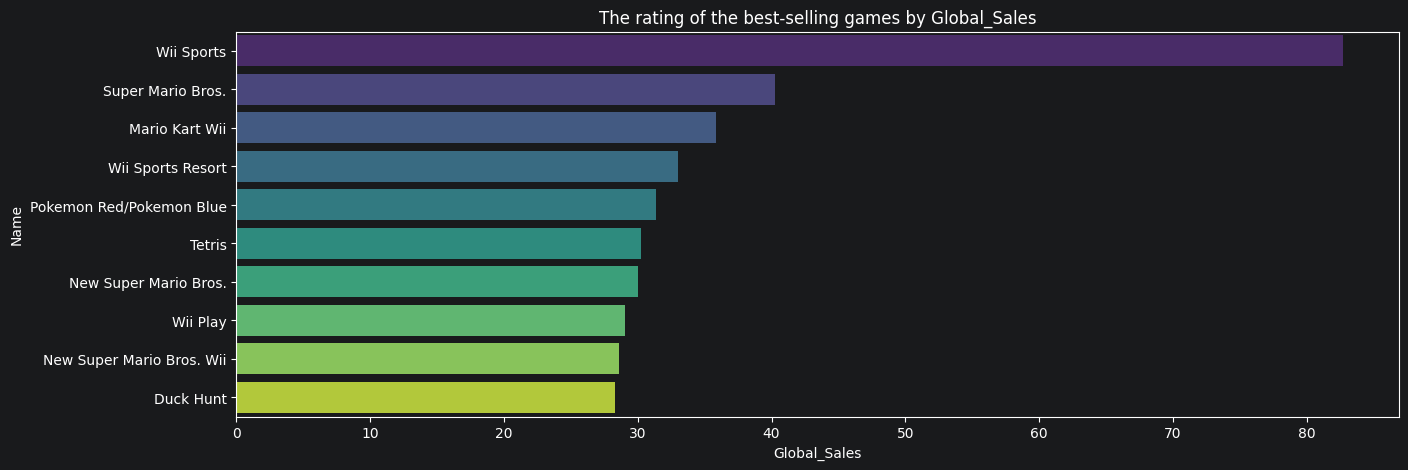

In [351]:
for i in cols_sales:
    plt.figure(figsize=(15, 5))
    temp_df_for_sales = df.nlargest(10,i).reset_index(drop=True)
    sns.barplot(
        x=i,
        y="Name",
        data=temp_df_for_sales,
        palette="viridis",
    )
    plt.title(f"The rating of the best-selling games by {i}")
    plt.show()

It is seen here that the Wii Sports are the most selling in most of the regions, except Japan which has Pokémon and Other sales with GTA San Andreas. Now let's make a rating of the globally most selling sames per every 5 years


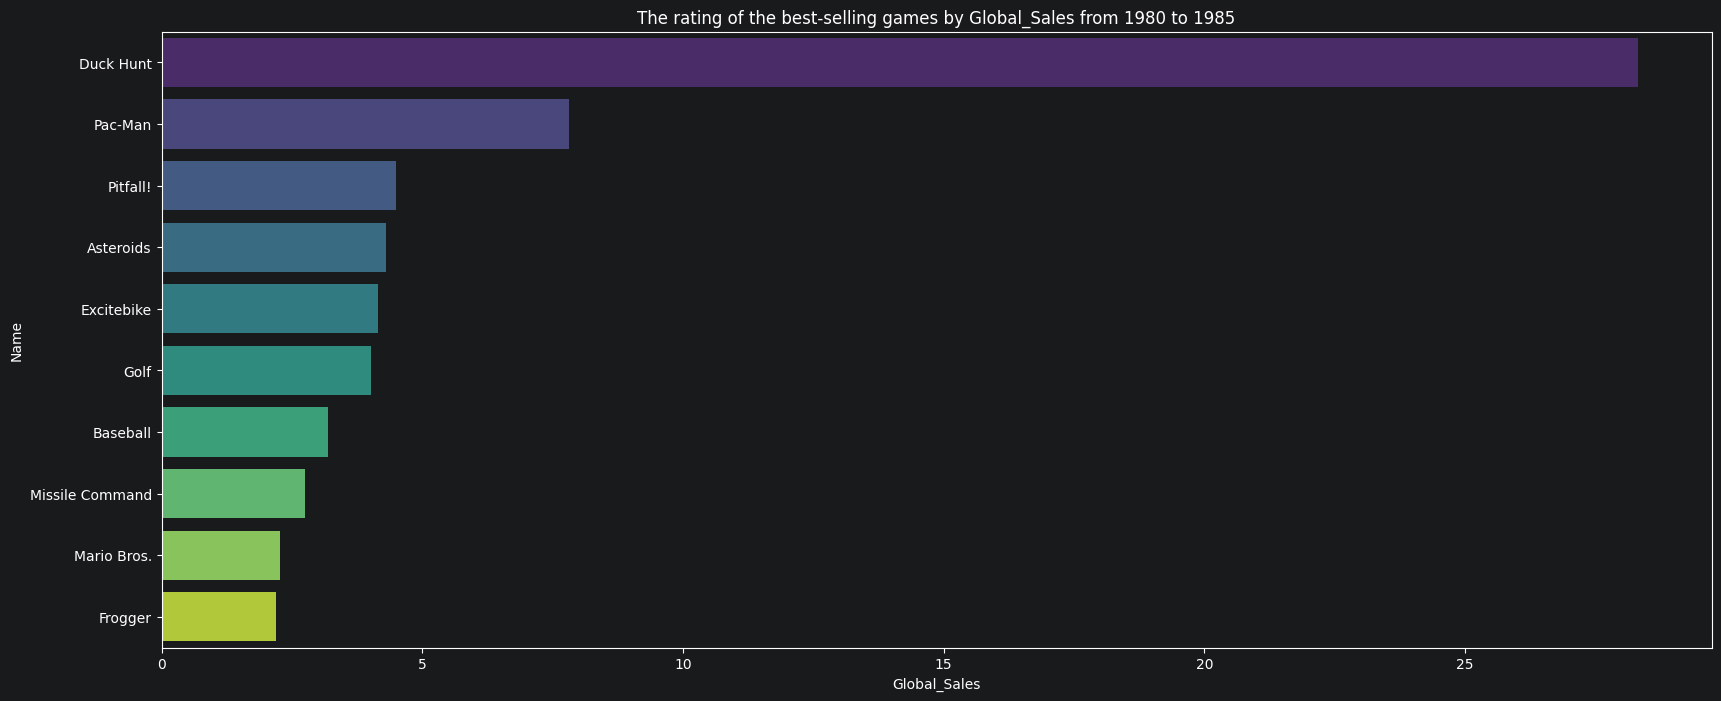

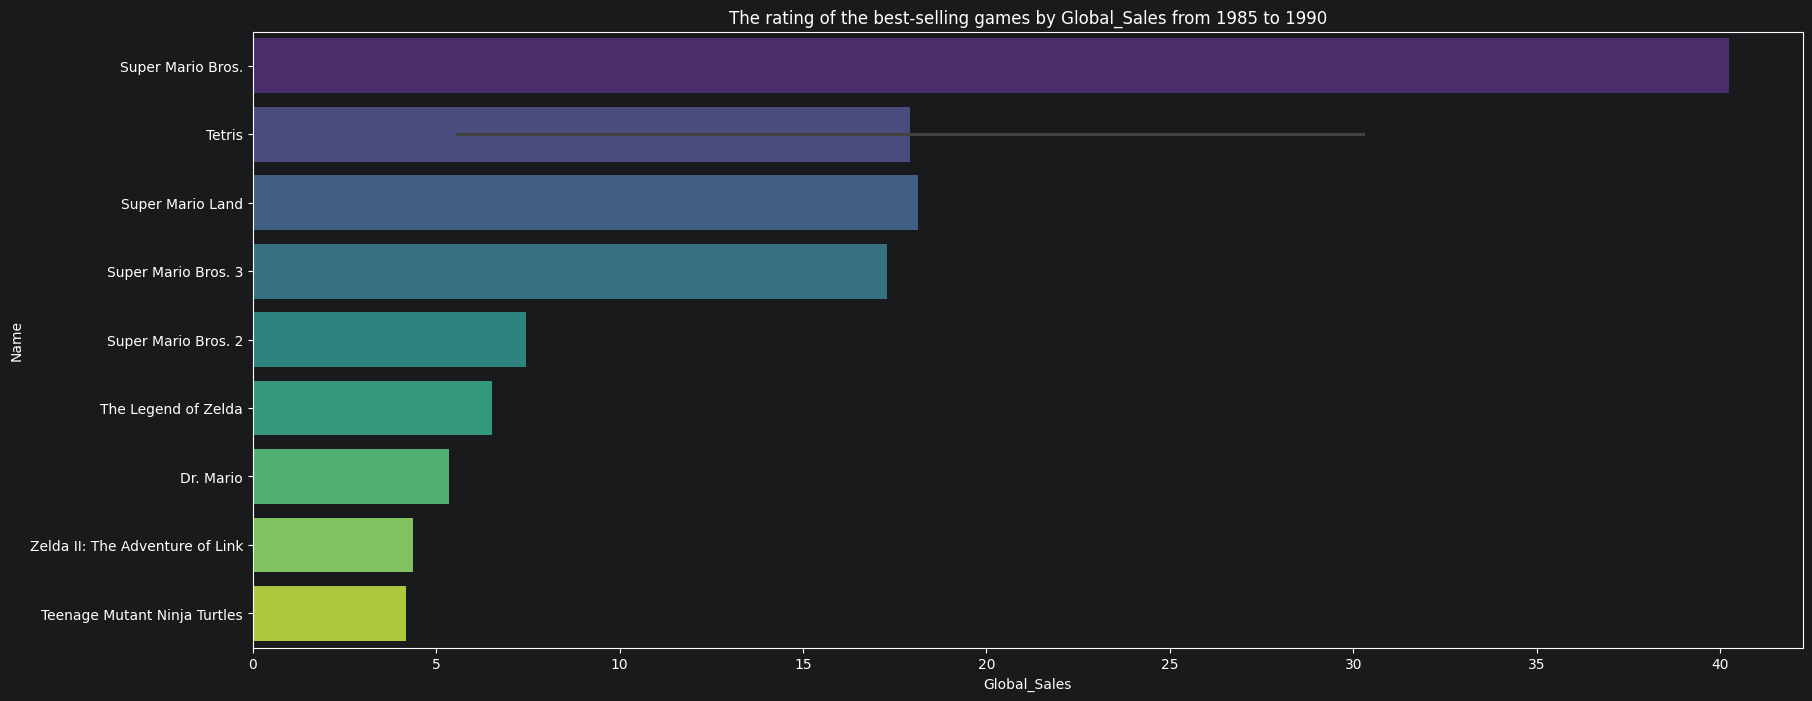

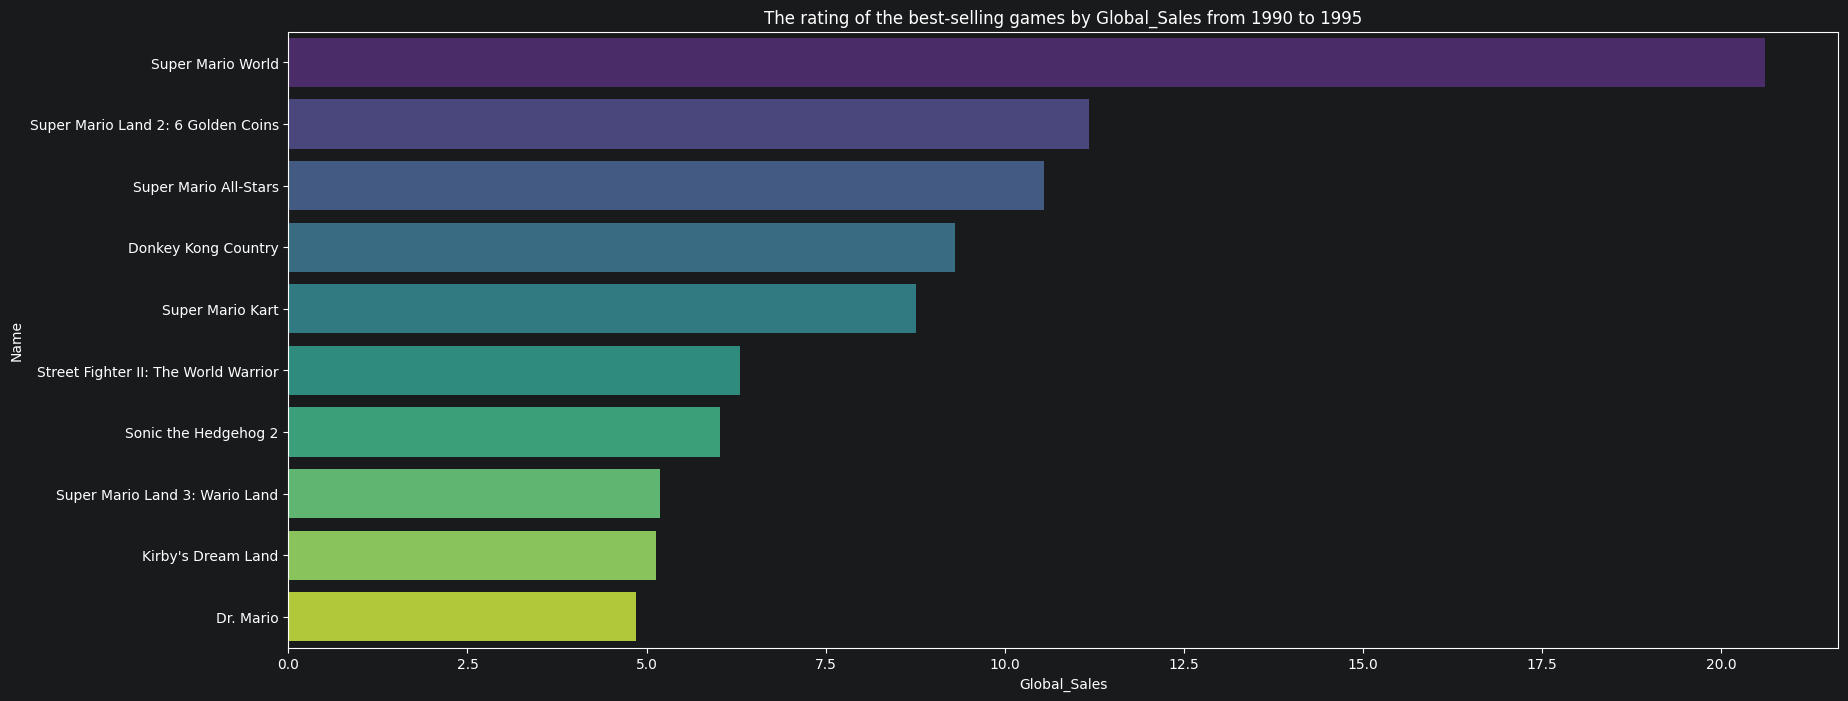

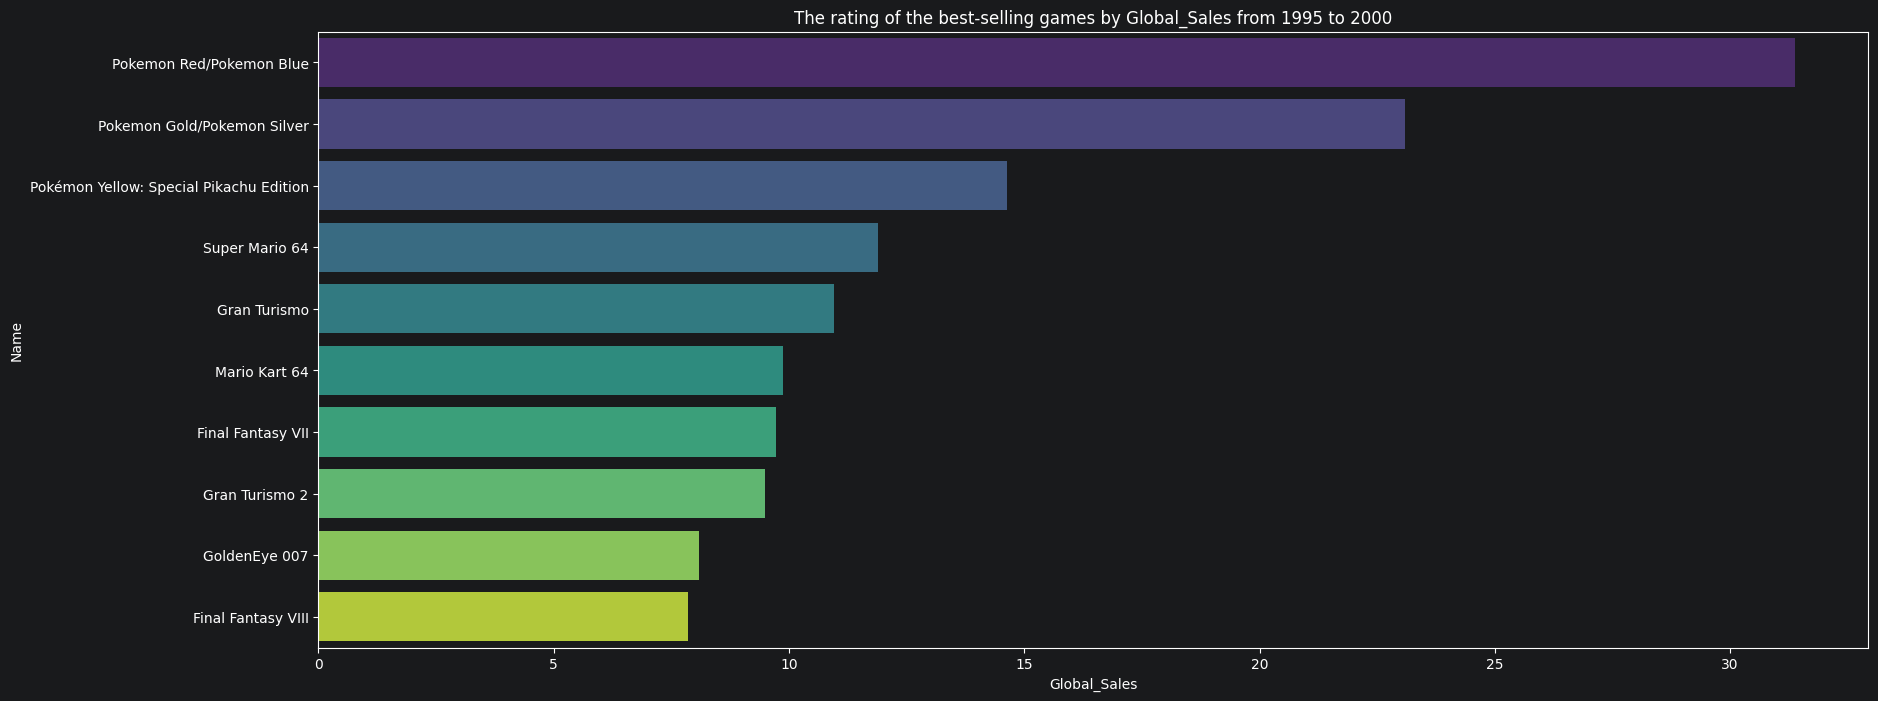

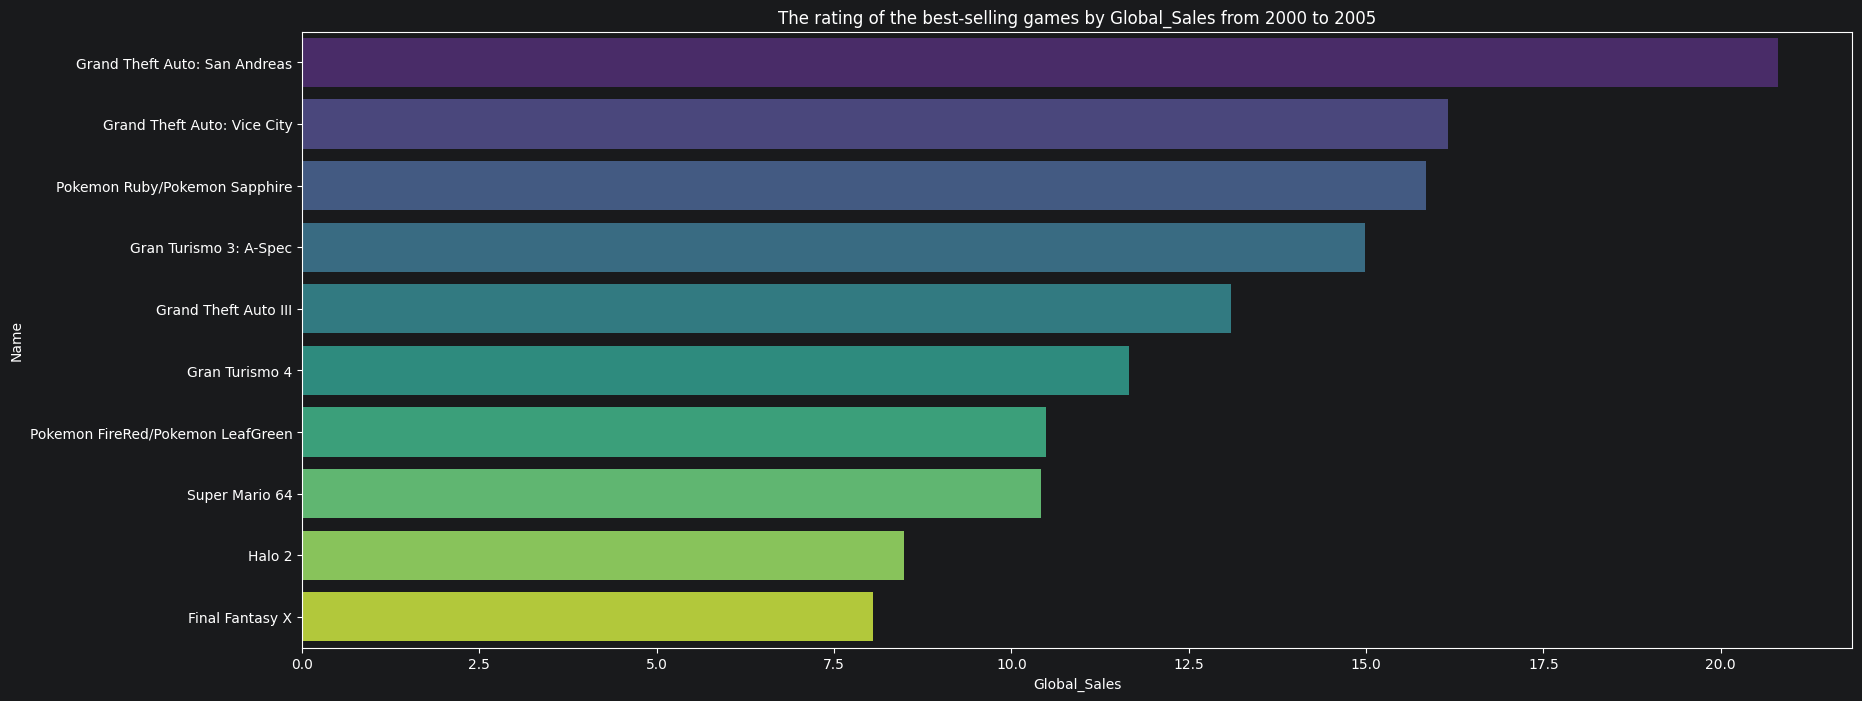

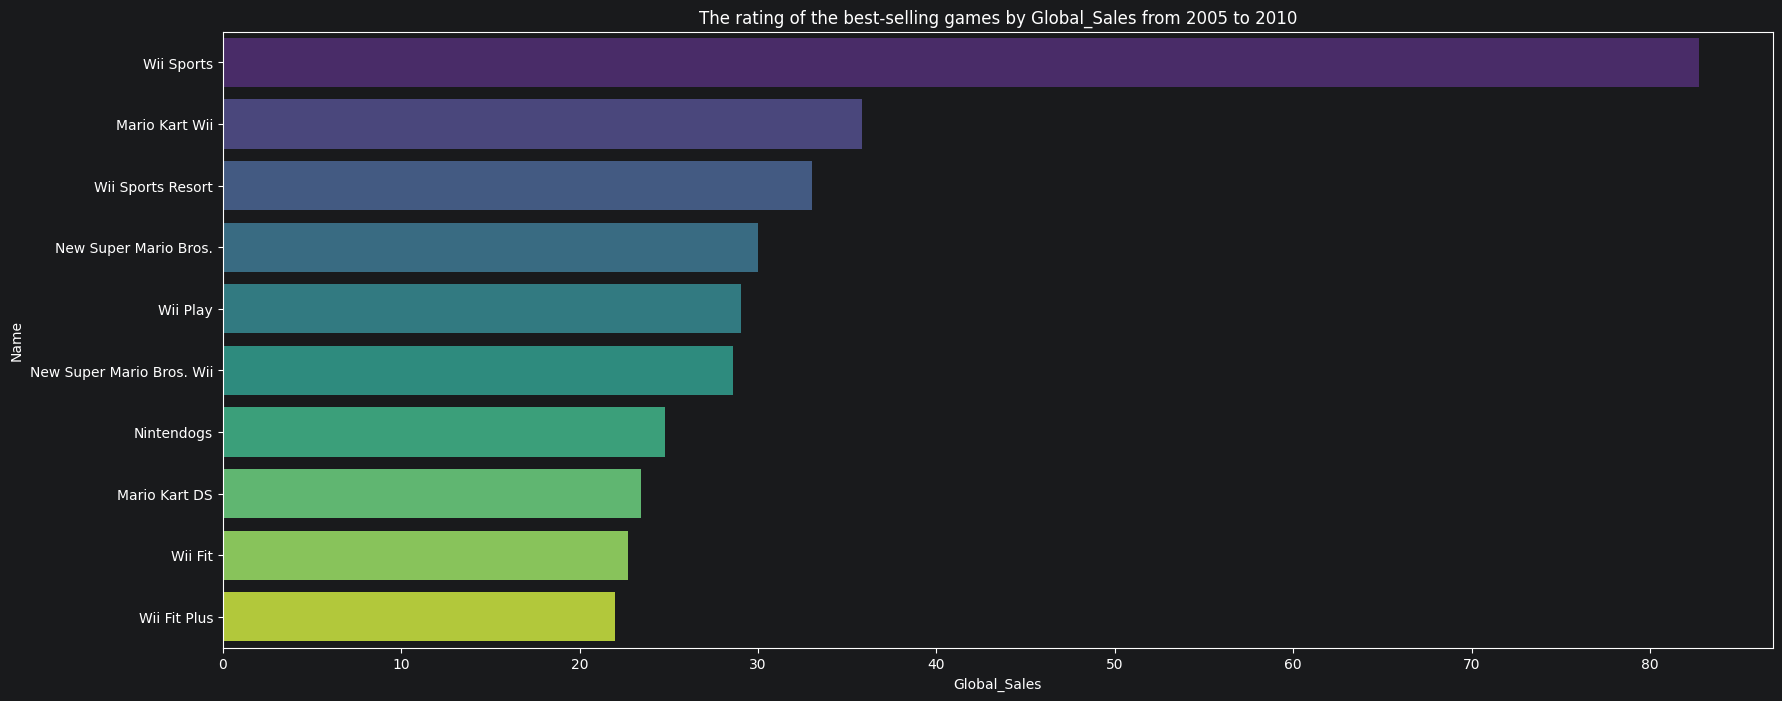

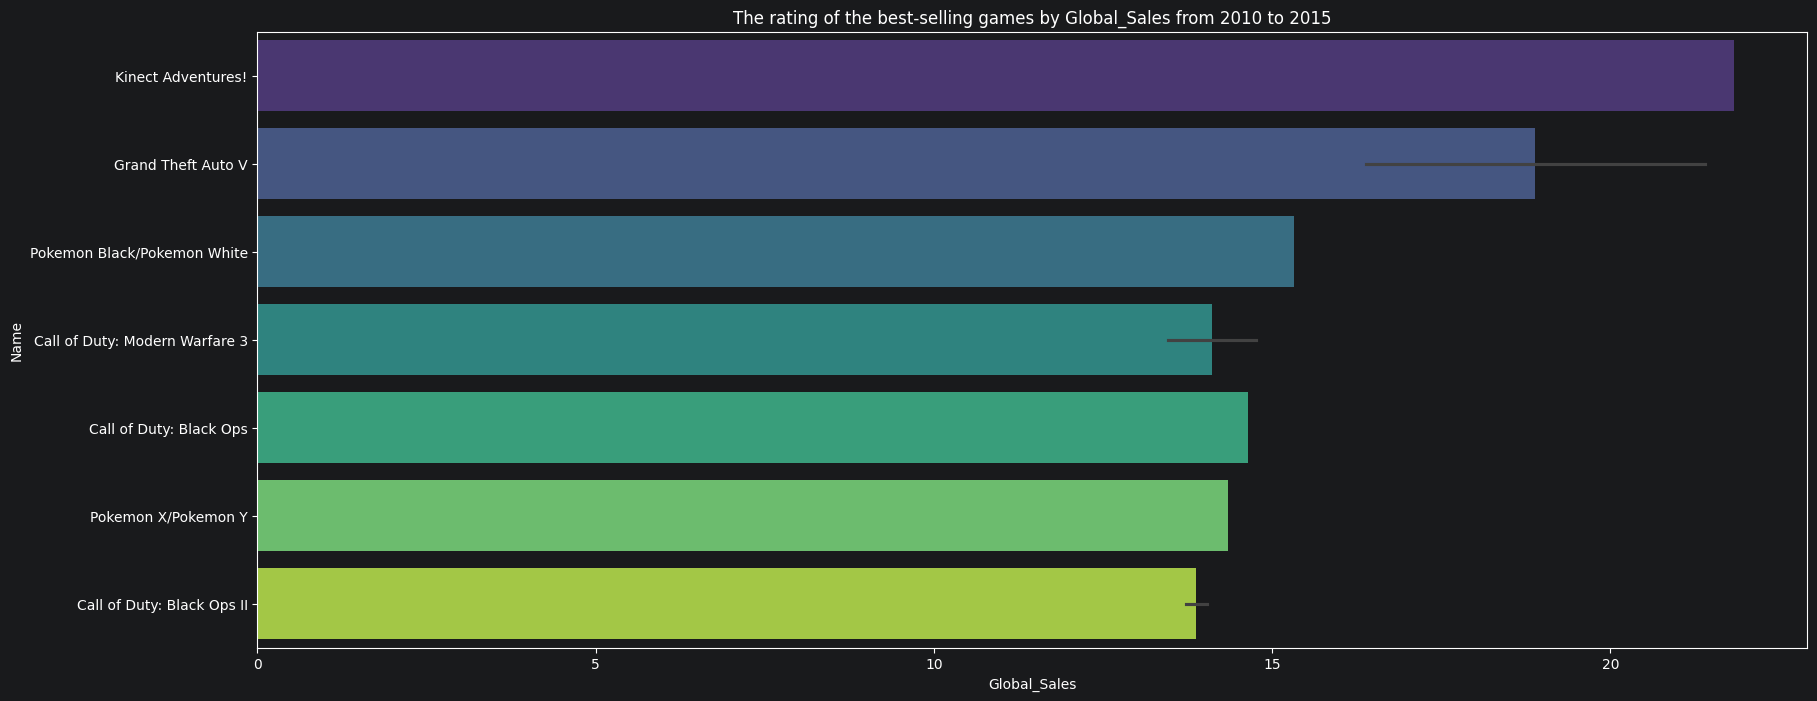

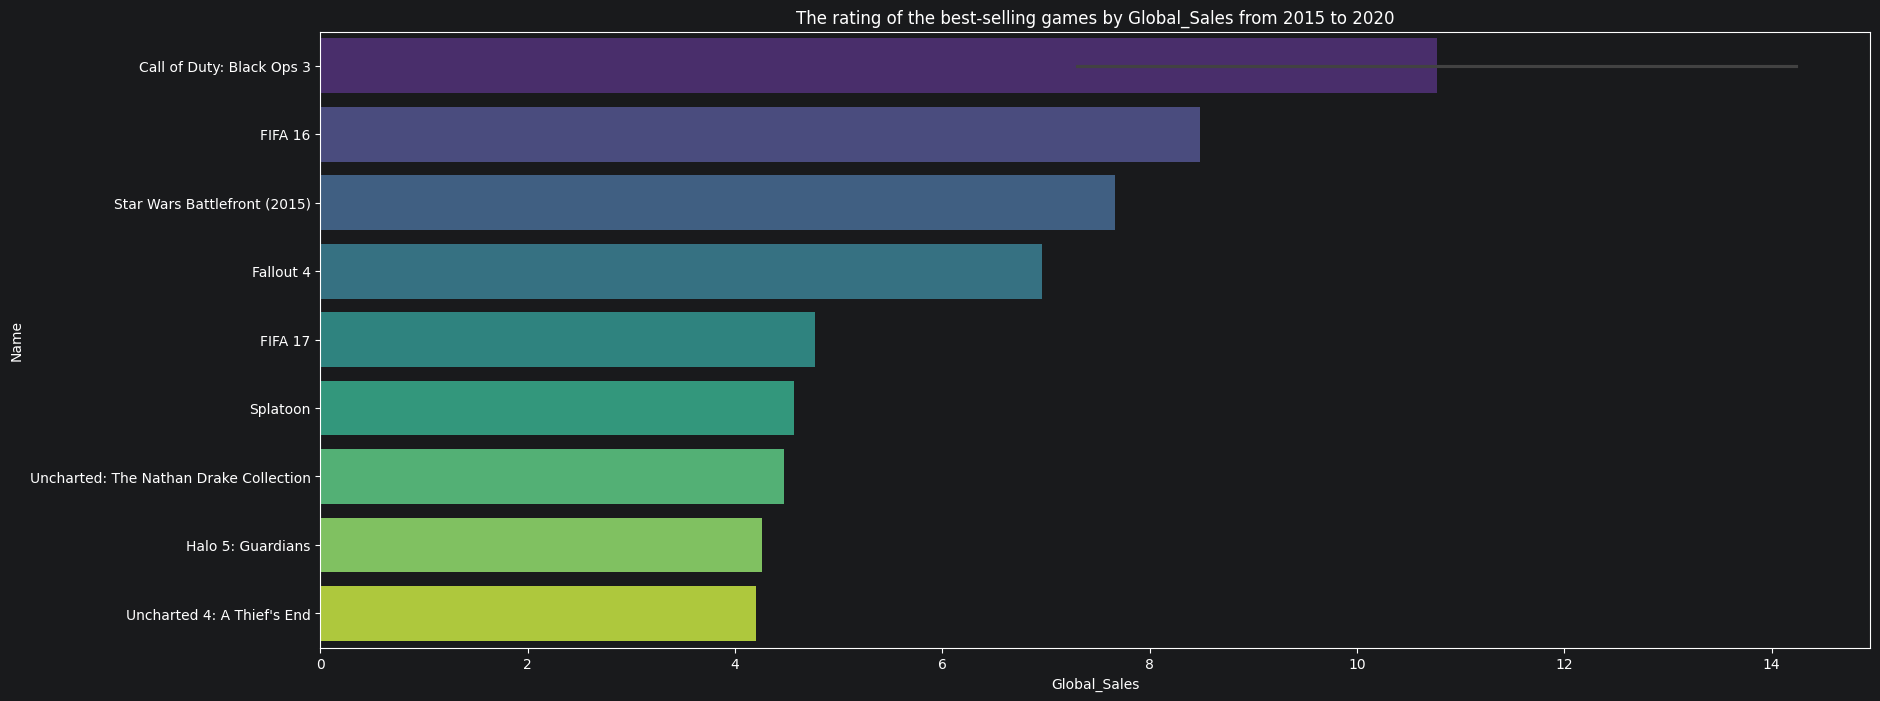

In [352]:
for i in range(1980,2016,5):
    temp_df_per_years = df[(df["Year"]>=i) & (df['Year']<i+5)]
    plt.figure(figsize=(20, 8))
    temp_df_for_sales = temp_df_per_years.nlargest(10,"Global_Sales").reset_index(drop=True)
    sns.barplot(
        x="Global_Sales",
        y="Name",
        data=temp_df_for_sales,
        palette="viridis",
    )
    plt.title(f"The rating of the best-selling games by Global_Sales from {i} to {i+5}")
    plt.show()



Here we see the globally most popular games per every 5 years. Lets do the same with publishers

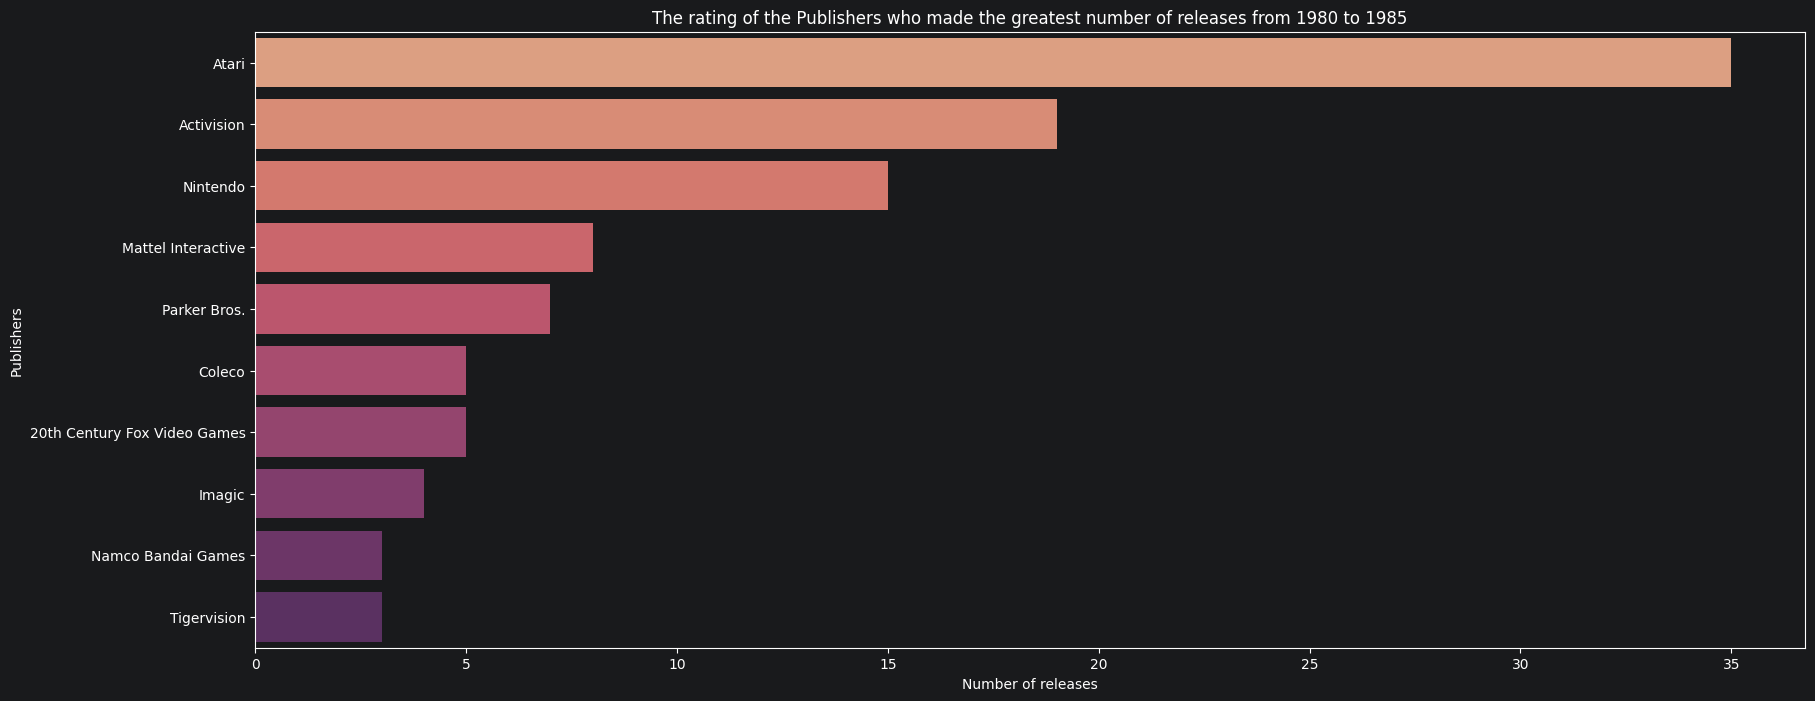

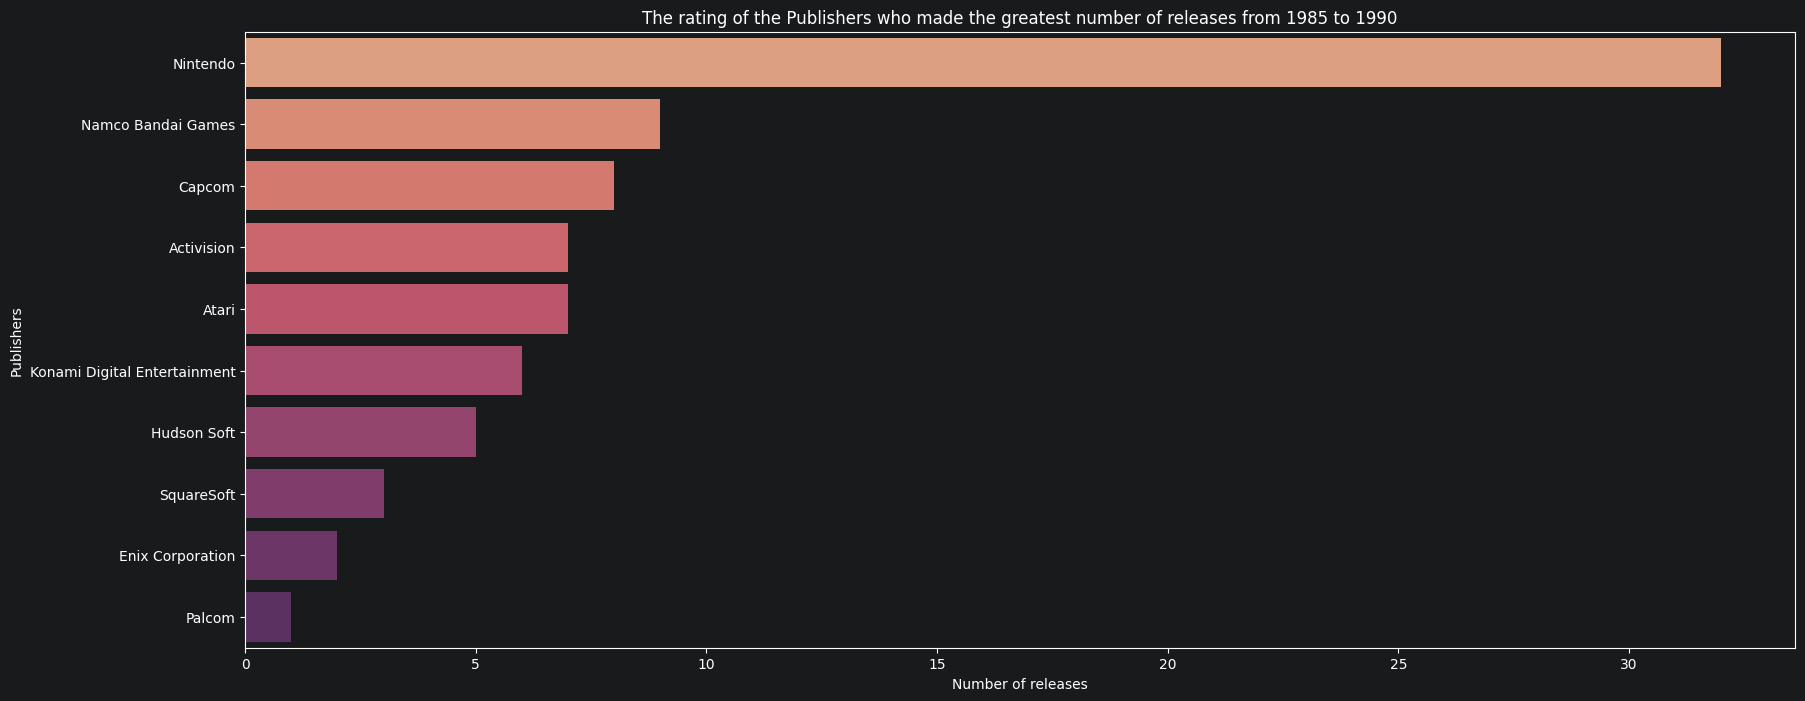

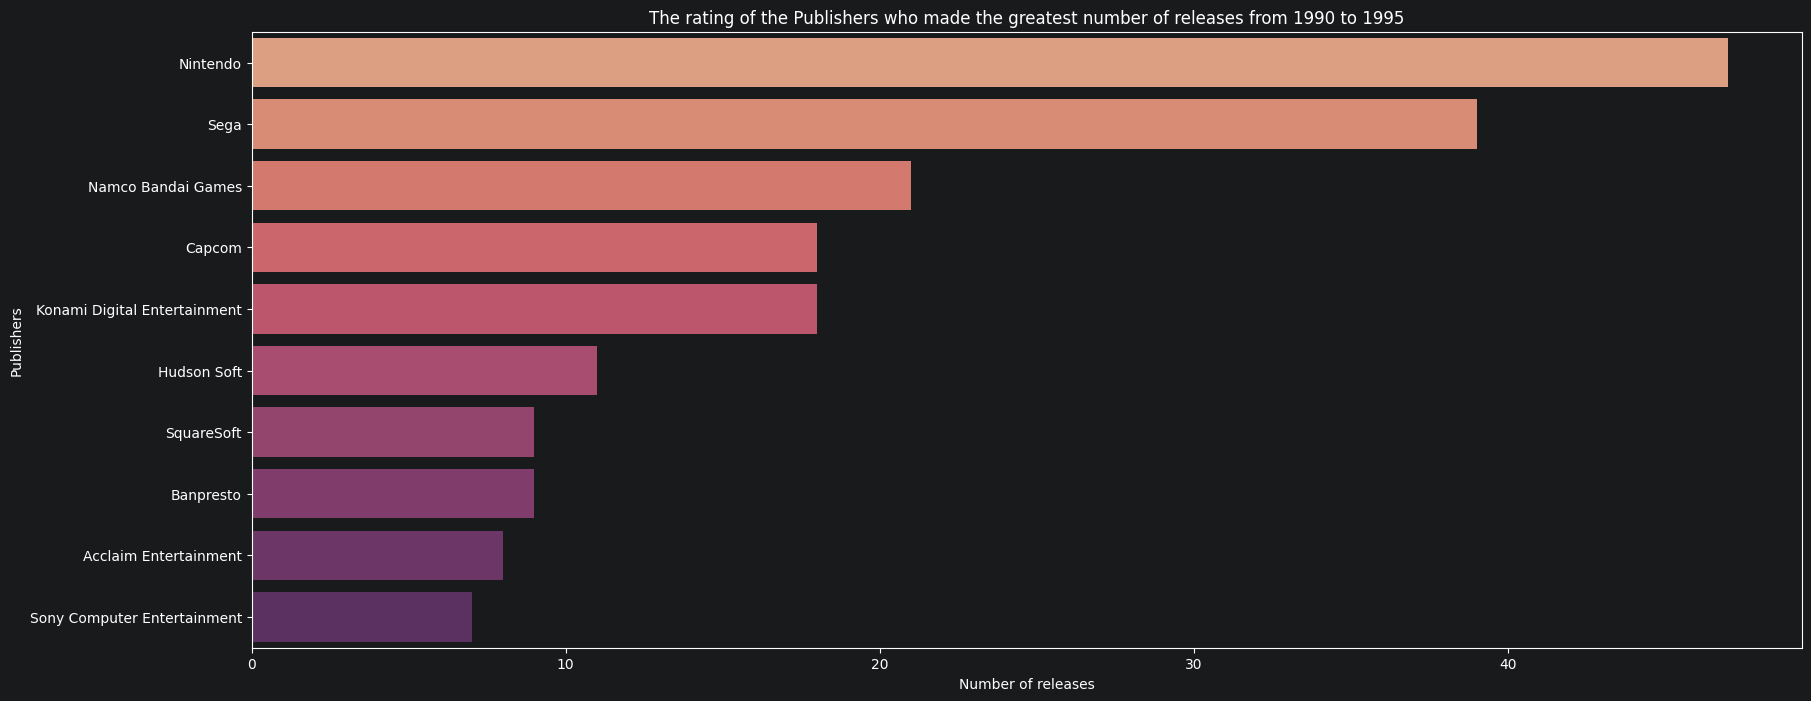

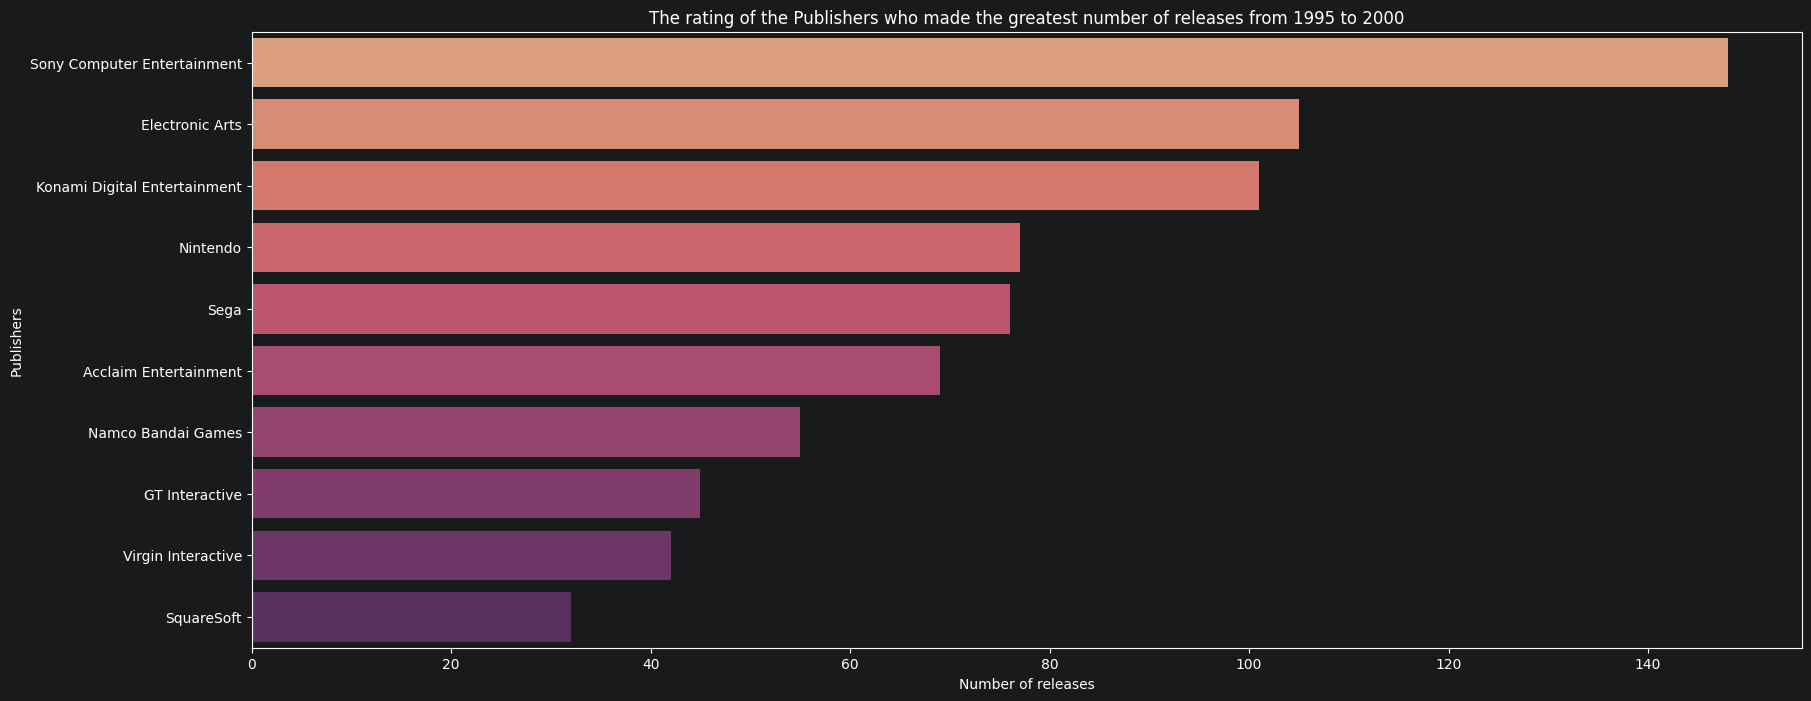

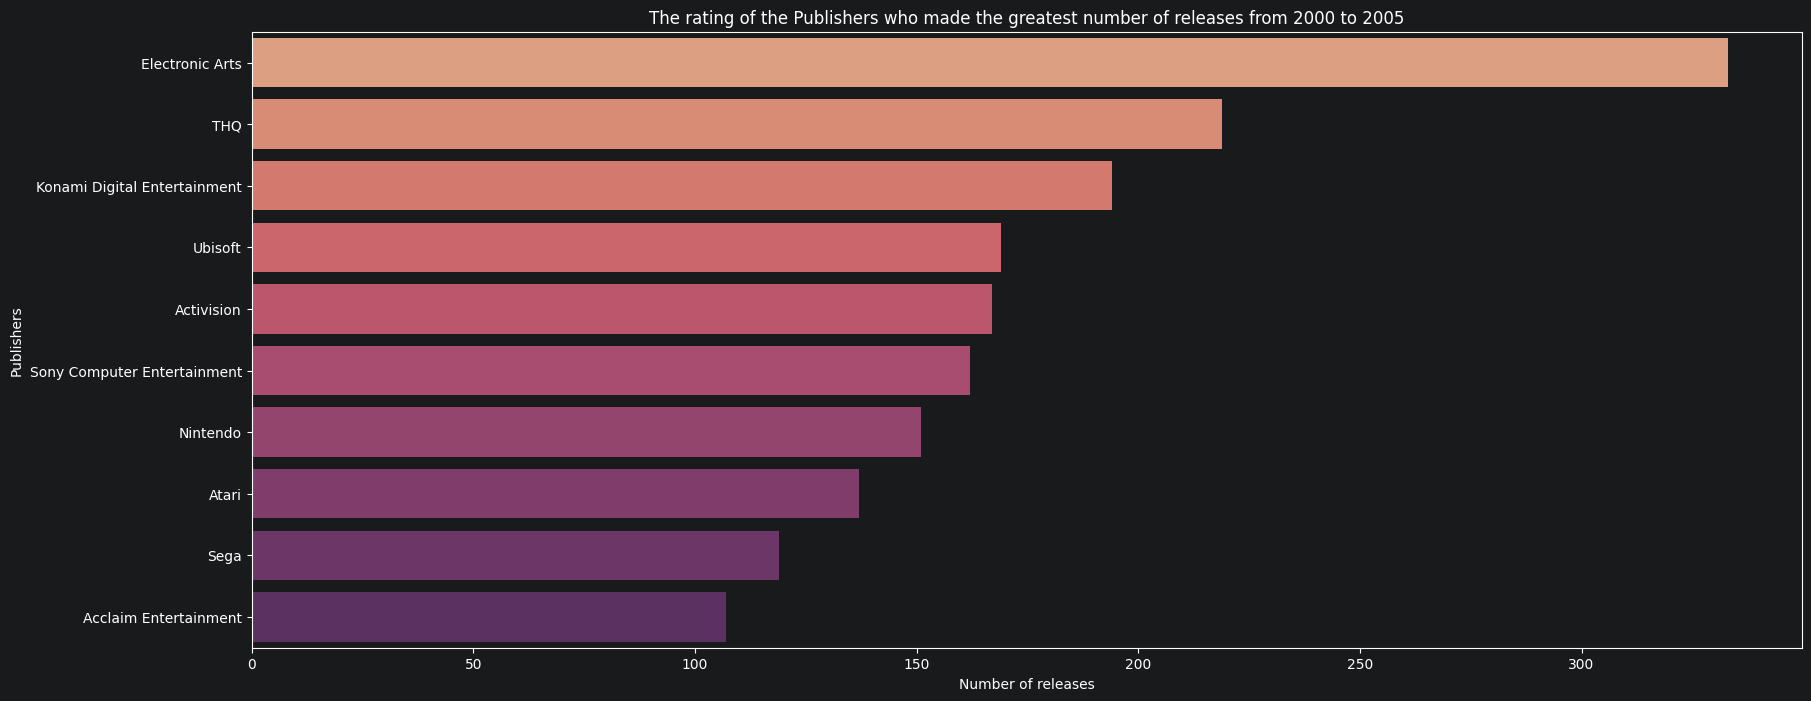

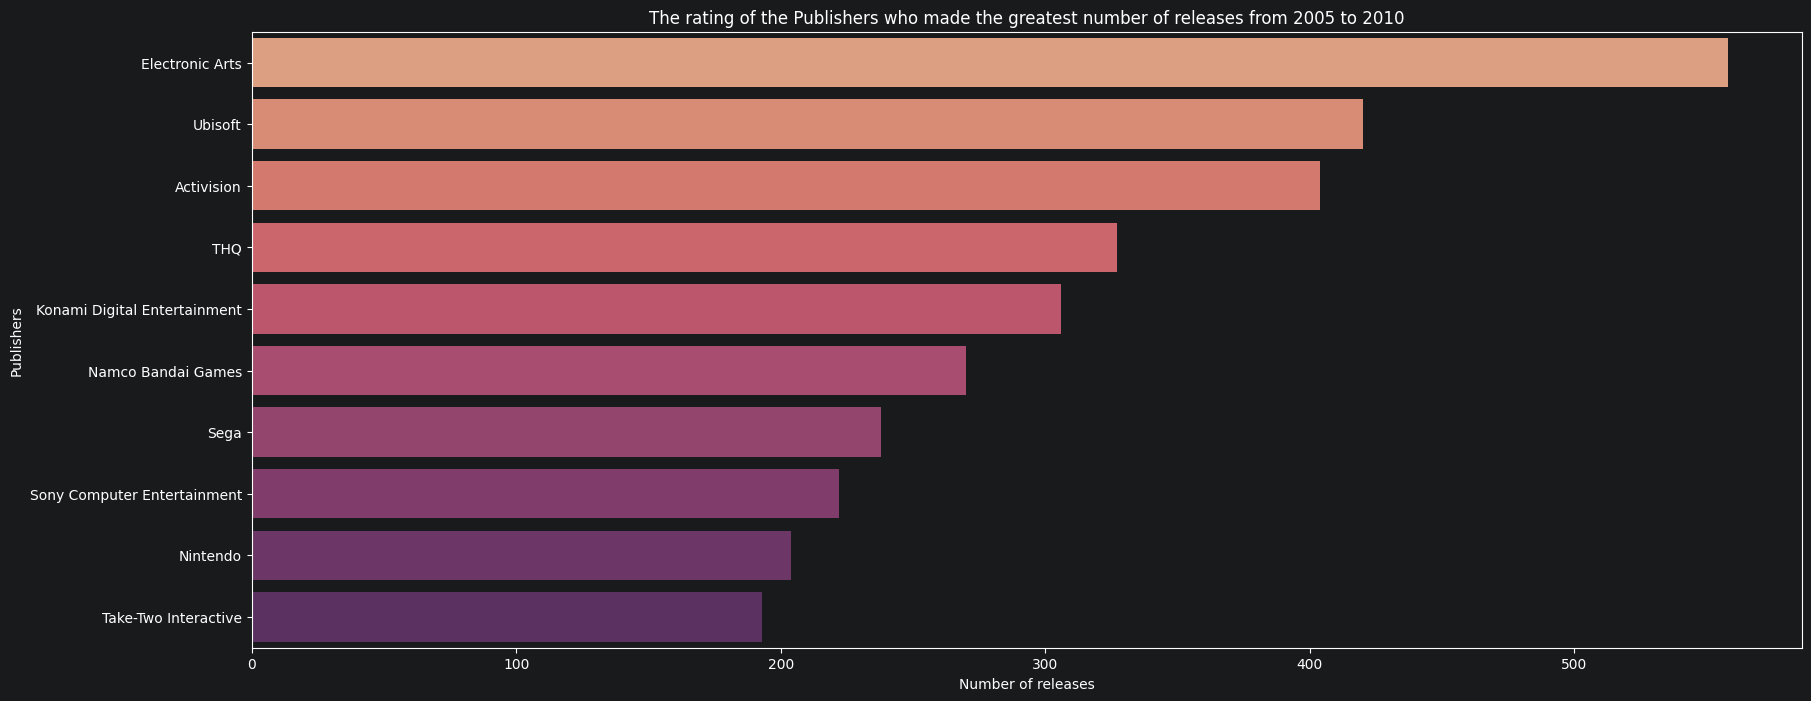

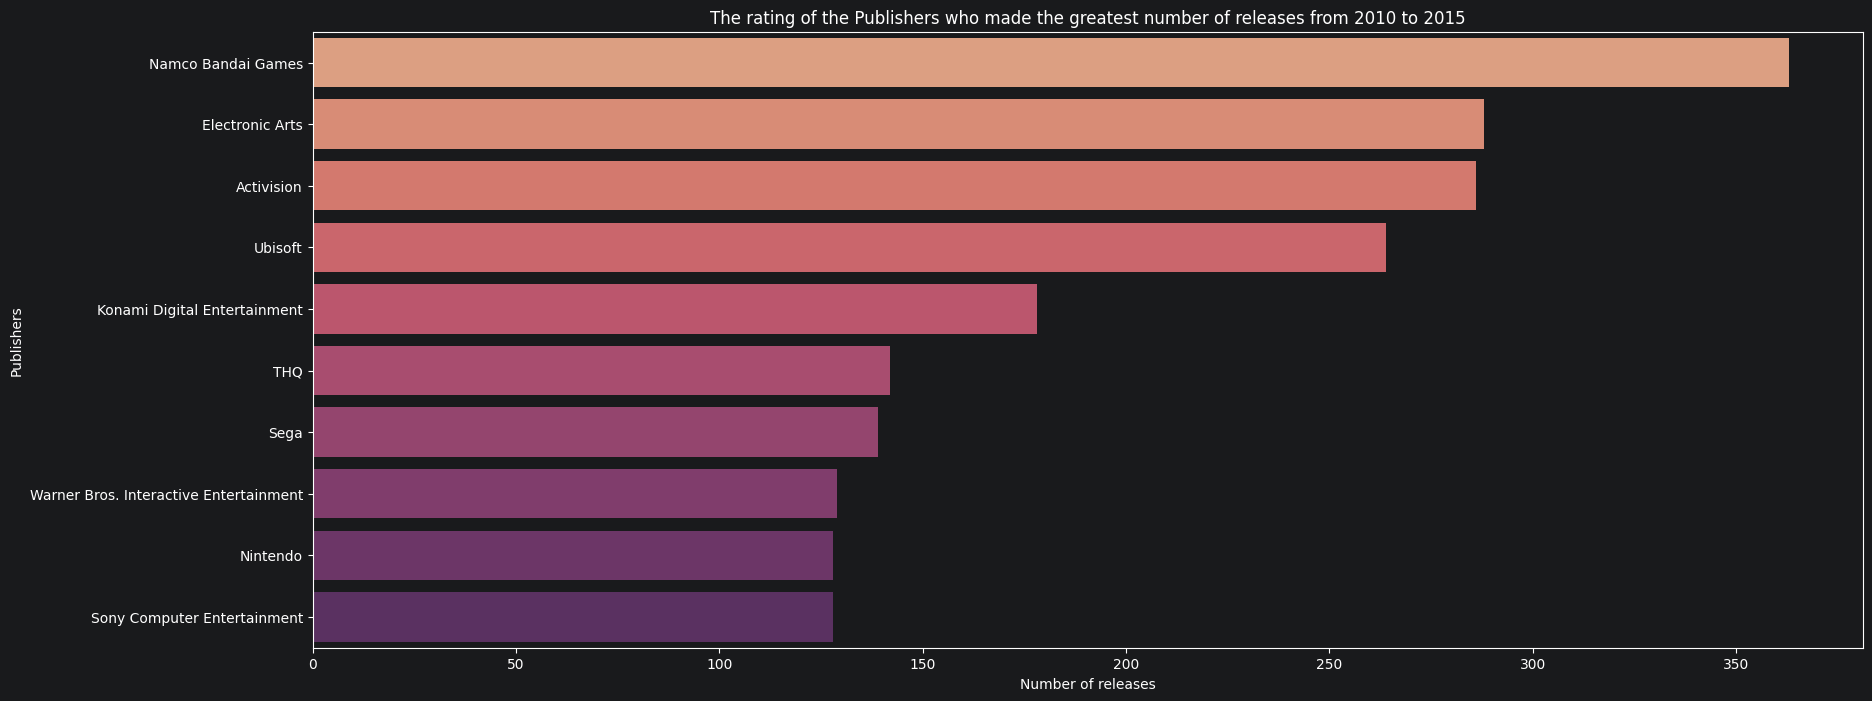

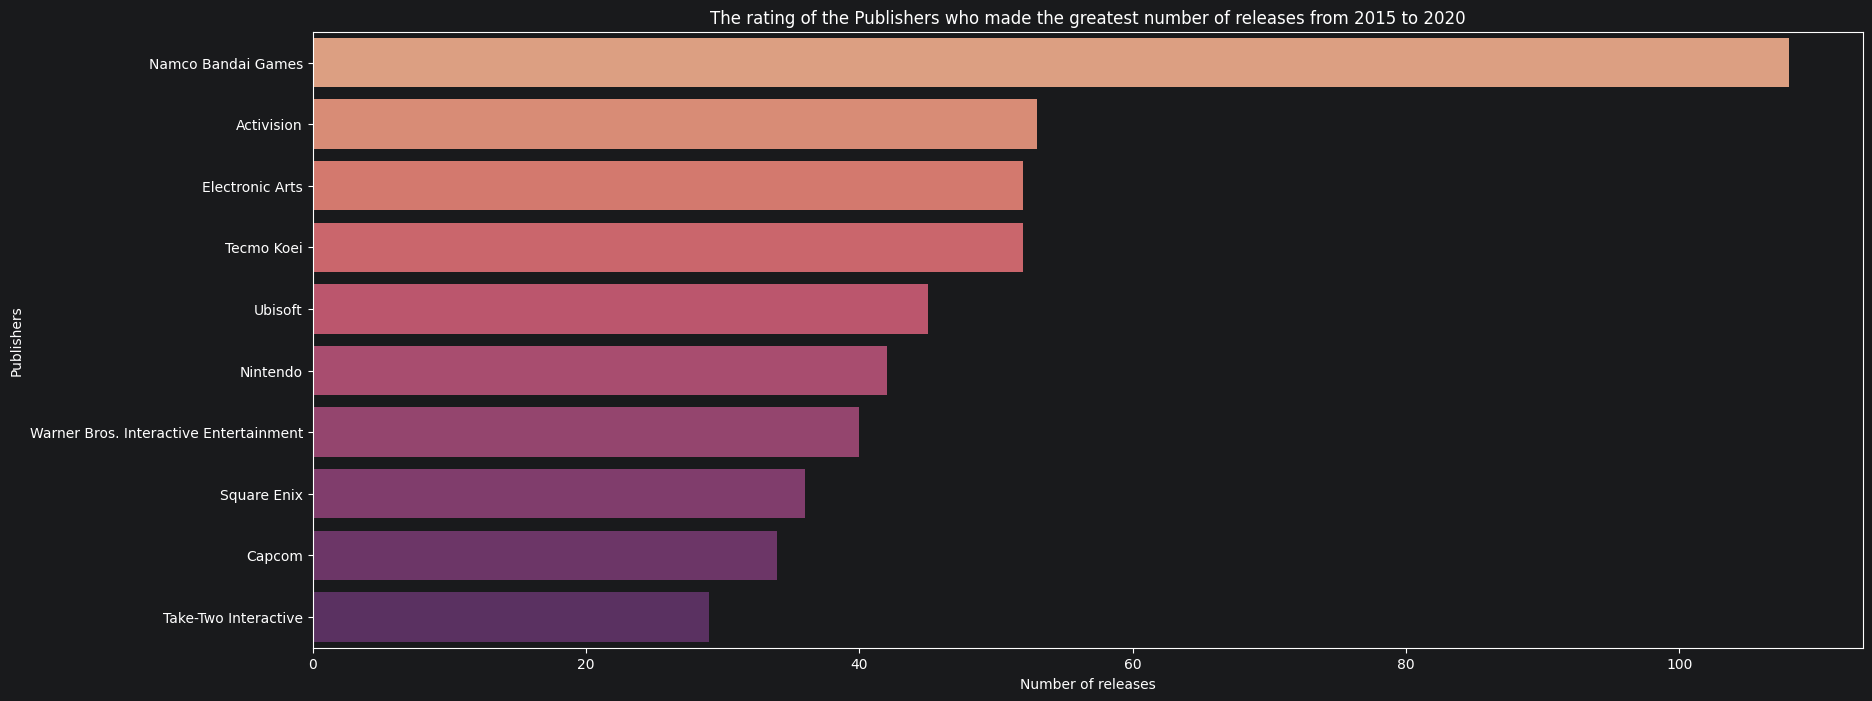

In [353]:
for i in range(1980,2016,5):
    temp_df_per_years = df[(df["Year"]>=i) & (df['Year']<i+5)]
    temp_indexes_of_publishers = temp_df_per_years["Publisher"].value_counts().head(10).index
    plt.figure(figsize=(20, 8))
    sns.countplot(
        temp_df_per_years[temp_df_per_years["Publisher"].isin(temp_indexes_of_publishers)]["Publisher"],
        order=temp_df_per_years[temp_df_per_years["Publisher"].isin(temp_indexes_of_publishers)]["Publisher"].value_counts().index,
        palette="flare",
    )
    plt.title(f"The rating of the Publishers who made the greatest number of releases from {i} to {i+5}")
    plt.xlabel("Number of releases")
    plt.ylabel("Publishers")
    plt.show()

We also can make a bars to compare the popularity of genres per every given region

In [354]:
cols_sales.remove("Global_Sales")

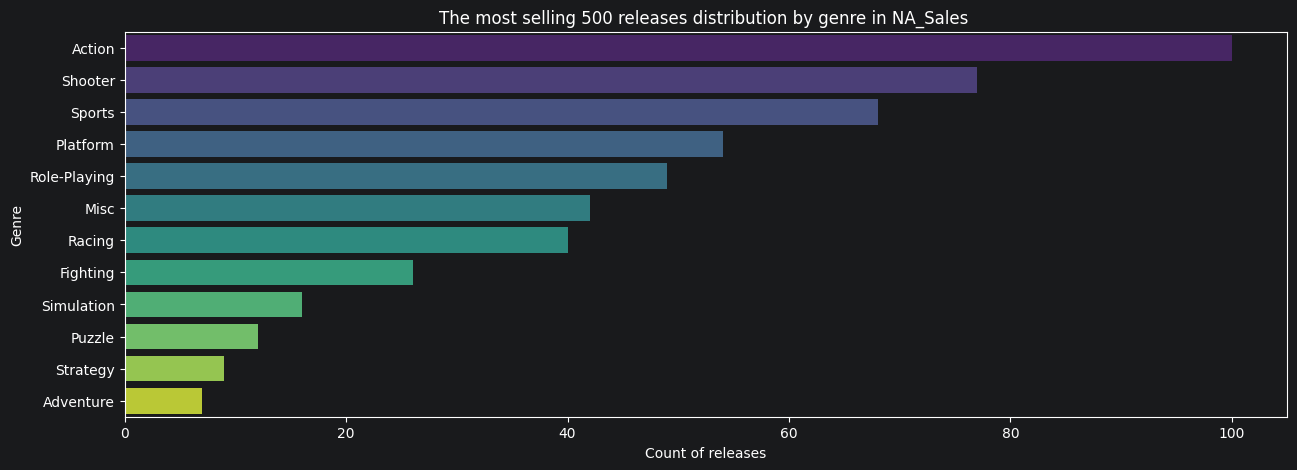

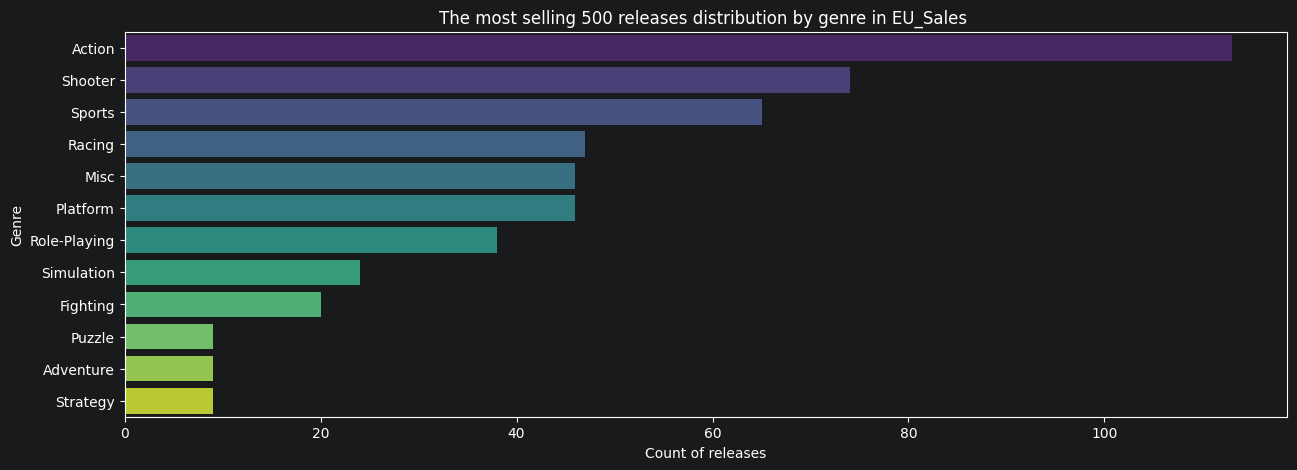

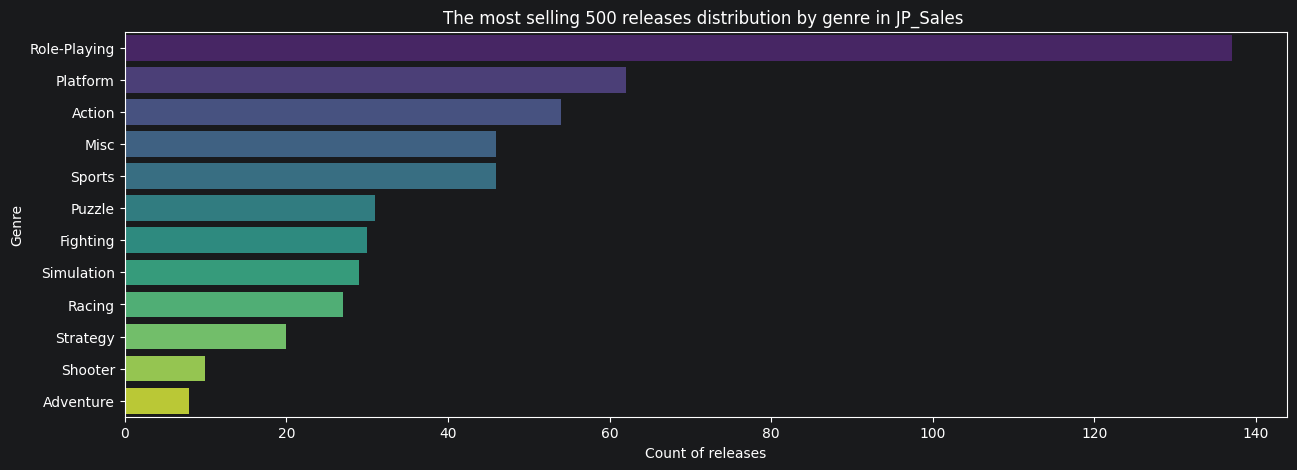

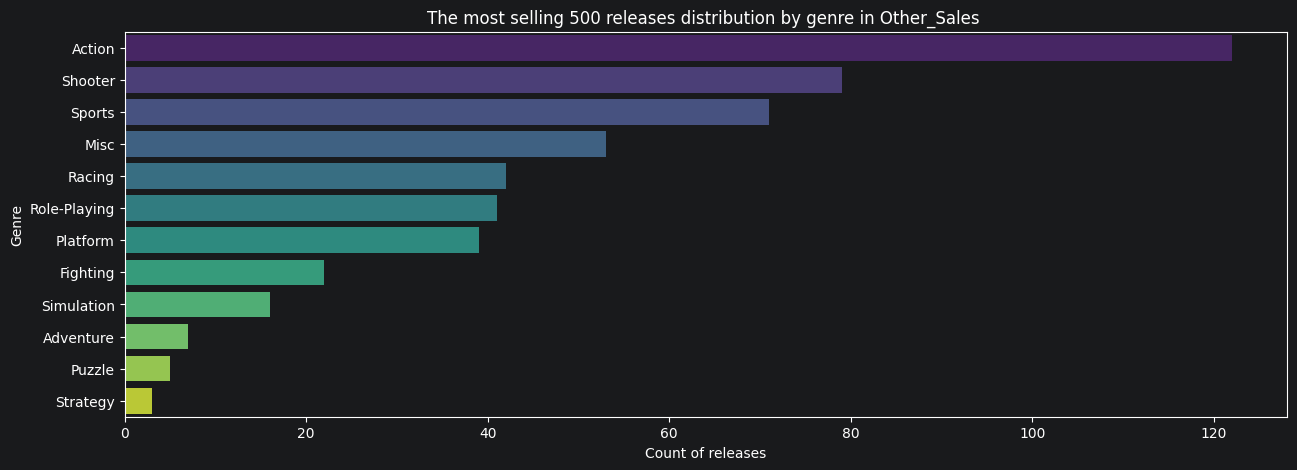

In [355]:
for i in cols_sales:
    plt.figure(figsize=(15, 5))
    df_extracted = df.sort_values(by=i, ascending=False).reset_index(drop=True)[:500]
    sns.countplot(df_extracted["Genre"], palette="viridis", order=df_extracted["Genre"].value_counts().index)
    plt.title(f"The most selling 500 releases distribution by genre in {i} ")
    plt.xlabel("Count of releases")
    plt.ylabel("Genre")
    plt.show()

Action and shooters are allways at the top, only JP loves Role playing games more

At the end, lets try to see some correlations

<Axes: >

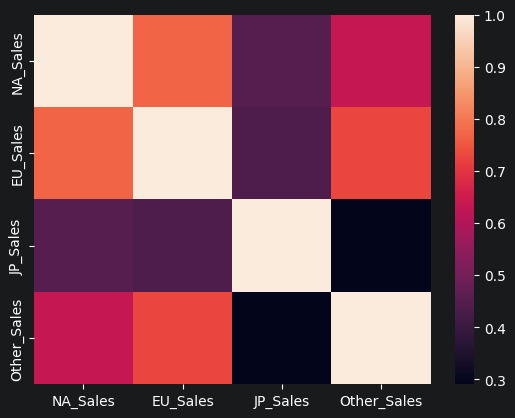

In [356]:
sns.heatmap(df[cols_sales].corr())

We can see here that Global sales and NA sales, EU sales and Global sales have a good correlation

<Axes: >

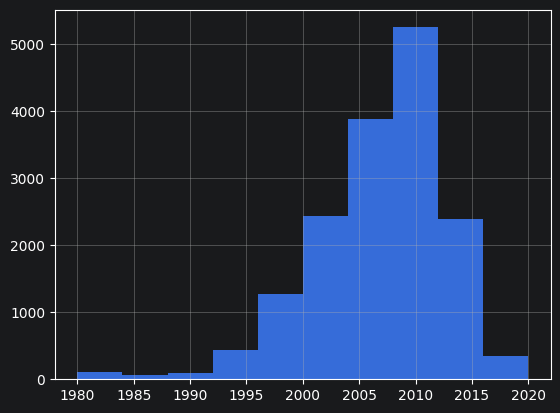

In [357]:
df["Year"].hist()

<Axes: ylabel='Density'>

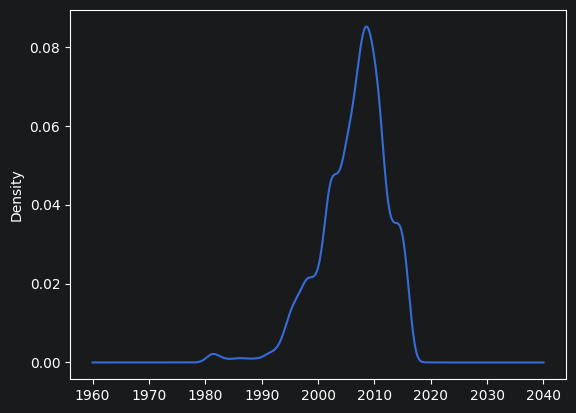

In [359]:
df["Year"].plot(
    kind="density",
)

<Axes: xlabel='Year', ylabel='Count'>

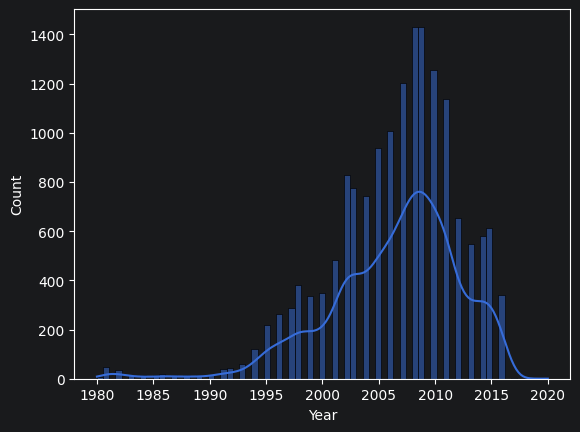

In [362]:
sns.histplot(df["Year"], kde=True)

<Axes: ylabel='Year'>

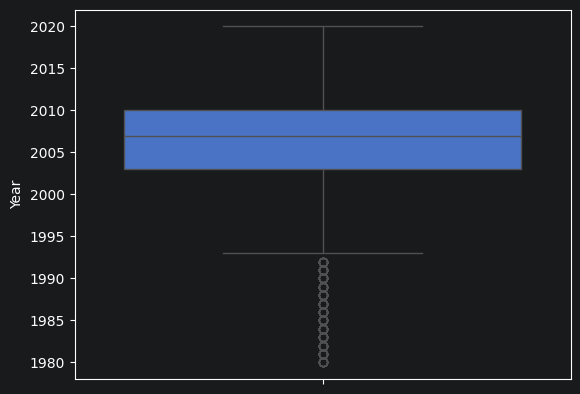

In [363]:
sns.boxplot(df["Year"])